# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [1]:
import pandas as pd
import numpy as np

# Load rainfall CSV
rain_raw = pd.read_csv("data/snotel_rainfall_data.csv")

rain_raw.head(), rain_raw.describe(include="all")

(         Date            Precip_in
 0  2024-01-01  0.14028030062619642
 1  2024-01-02   0.6590180328421851
 2  2024-01-03                  0.0
 3  2024-01-04                  0.0
 4  2024-01-05   0.3757291395473922,
               Date Precip_in
 count           61        58
 unique          60        32
 top     2024-01-16       0.0
 freq             2        27)

## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [2]:
# Try to identify likely columns
rain_raw.columns

# Heuristic: pick the first column that looks like a date, and the first non-date numeric-ish column
date_col = rain_raw.columns[0]
value_col = rain_raw.columns[1] if len(rain_raw.columns) > 1 else rain_raw.columns[0]

# Parse date
rain_raw[date_col] = pd.to_datetime(rain_raw[date_col], errors="coerce")

# Coerce rainfall values to numeric
rain_raw[value_col] = pd.to_numeric(rain_raw[value_col], errors="coerce")

# Build the requested DataFrame name: Rainfall_mm
Rainfall_mm = rain_raw[[date_col, value_col]].dropna(subset=[date_col]).set_index(date_col).sort_index()
Rainfall_mm.columns = ["rain_mm"]

Rainfall_mm.head(), Rainfall_mm.describe()

(             rain_mm
 Date                
 2024-01-01  0.140280
 2024-01-02  0.659018
 2024-01-03  0.000000
 2024-01-04  0.000000
 2024-01-05  0.375729,
           rain_mm
 count   56.000000
 mean    -8.467089
 std    150.395286
 min   -999.000000
 25%      0.000000
 50%      0.050563
 75%      0.682890
 max    500.000000)

## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [3]:
flow_raw = pd.read_csv("data/streamflow_data.csv")

flow_raw.head(), flow_raw.describe(include="all")

# Identify columns similarly
flow_date_col = flow_raw.columns[0]
flow_value_col = flow_raw.columns[1] if len(flow_raw.columns) > 1 else flow_raw.columns[0]

flow_raw[flow_date_col] = pd.to_datetime(flow_raw[flow_date_col], errors="coerce")
flow_raw[flow_value_col] = pd.to_numeric(flow_raw[flow_value_col], errors="coerce")

streamflow_cfs = flow_raw[[flow_date_col, flow_value_col]].dropna(subset=[flow_date_col]).set_index(flow_date_col).sort_index()
streamflow_cfs.columns = ["flow_cfs"]

# More useful stats:
stats = streamflow_cfs["flow_cfs"].agg(["count","mean","median","min","max","std"])
quantiles = streamflow_cfs["flow_cfs"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

streamflow_cfs.head(), streamflow_cfs.describe(), stats, quantiles

(            flow_cfs
 Date                
 2024-01-01     10.25
 2024-01-02     10.70
 2024-01-03     13.30
 2024-01-04     10.10
 2024-01-05     10.00,
           flow_cfs
 count    54.000000
 mean     40.058333
 std     369.096212
 min    -999.000000
 25%      10.100000
 50%      10.600000
 75%      13.900000
 max    2510.000000,
 count       54.000000
 mean        40.058333
 median      10.600000
 min       -999.000000
 max       2510.000000
 std        369.096212
 Name: flow_cfs, dtype: float64,
 0.05    10.0000
 0.25    10.1000
 0.50    10.6000
 0.75    13.9000
 0.95    21.3525
 Name: flow_cfs, dtype: float64)

## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [10]:
# Replace common bad flags (-999) with NaN, and remove other obvious junk (negative rainfall/flow)
rain_clean0 = Rainfall_mm.copy()
flow_clean0 = streamflow_cfs.copy()

rain_clean0["rain_mm"] = rain_clean0["rain_mm"].replace(-999, np.nan)
flow_clean0["flow_cfs"] = flow_clean0["flow_cfs"].replace(-999, np.nan)

# Remove values that don't make physical sense (optional but usually correct)
rain_clean0.loc[rain_clean0["rain_mm"] < 0, "rain_mm"] = np.nan
flow_clean0.loc[flow_clean0["flow_cfs"] < 0, "flow_cfs"] = np.nan

# drop any duplicate timestamps – they cause reindex/concat errors later
rain_clean0 = rain_clean0[~rain_clean0.index.duplicated(keep='first')]
flow_clean0 = flow_clean0[~flow_clean0.index.duplicated(keep='first')]

# Method 1: drop gaps
rain_drop = rain_clean0.dropna()
flow_drop = flow_clean0.dropna()

# Method 2: fill with mean
rain_meanfill = rain_clean0.copy()
flow_meanfill = flow_clean0.copy()
rain_meanfill["rain_mm"] = rain_meanfill["rain_mm"].fillna(rain_meanfill["rain_mm"].mean())
flow_meanfill["flow_cfs"] = flow_meanfill["flow_cfs"].fillna(flow_meanfill["flow_cfs"].mean())

# Method 3: interpolate (time-based works well for time series)
rain_interp = rain_clean0.copy()
flow_interp = flow_clean0.copy()
rain_interp["rain_mm"] = rain_interp["rain_mm"].interpolate(method="time")
flow_interp["flow_cfs"] = flow_interp["flow_cfs"].interpolate(method="time")

(rain_clean0.isna().sum(), flow_clean0.isna().sum())

(rain_mm    6
 dtype: int64,
 flow_cfs    7
 dtype: int64)

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [11]:
# The original cleaned frames already share the same index (duplicates
# are allowed).  Rather than reindexing (which fails when the index
# contains duplicate labels) just concat the three series together.  The
# result will align on their indexes and keep duplicates intact.

rainfall_methods = pd.concat([
    rain_drop["rain_mm"],
    rain_meanfill["rain_mm"],
    rain_interp["rain_mm"]
], axis=1)
rainfall_methods.columns = ["dropna", "mean_fill", "interpolate"]

streamflow_methods = pd.concat([
    flow_drop["flow_cfs"],
    flow_meanfill["flow_cfs"],
    flow_interp["flow_cfs"]
], axis=1)
streamflow_methods.columns = ["dropna", "mean_fill", "interpolate"]

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

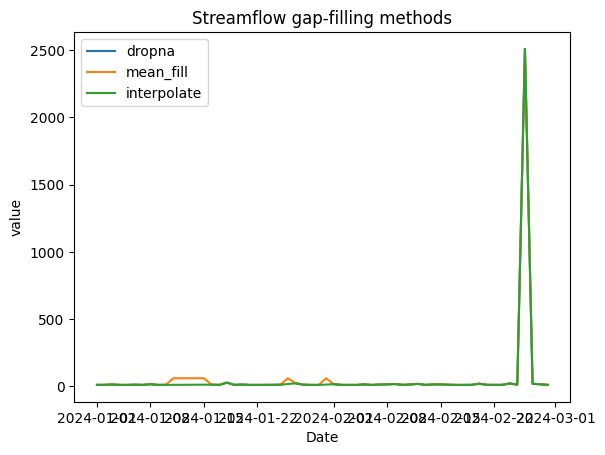

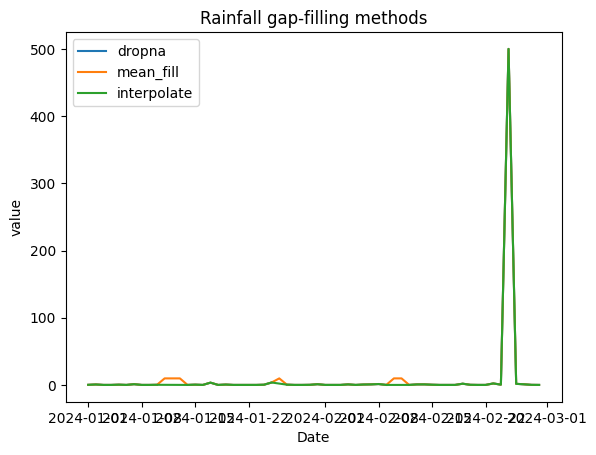

In [12]:
import matplotlib.pyplot as plt

# visualize gap‑filling methods for a DataFrame of series
def plot_methods(df, title):
    fig, ax = plt.subplots()
    for name in df.columns:
        series = pd.to_numeric(df[name], errors='coerce')  # ensure numeric
        ax.plot(df.index, series, label=name)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('value')
    plt.show()

# if the helper frames don't yet exist (e.g. after restarting the kernel),
# rebuild them from the cleaned series so plotting always works.
if 'streamflow_methods' not in globals():
    streamflow_methods = pd.concat([
        flow_drop["flow_cfs"],
        flow_meanfill["flow_cfs"],
        flow_interp["flow_cfs"]
    ], axis=1)
    streamflow_methods.columns = ["dropna", "mean_fill", "interpolate"]

if 'rainfall_methods' not in globals():
    rainfall_methods = pd.concat([
        rain_drop["rain_mm"],
        rain_meanfill["rain_mm"],
        rain_interp["rain_mm"]
    ], axis=1)
    rainfall_methods.columns = ["dropna", "mean_fill", "interpolate"]

plot_methods(streamflow_methods, 'Streamflow gap‑filling methods')
plot_methods(rainfall_methods, 'Rainfall gap‑filling methods')

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [14]:
# choose the interpolated series for both variables and merge into one frame
# use the cleaned column names from earlier
rain_flow_df = pd.DataFrame({
    'rain_mm': rain_interp['rain_mm'],
    'flow_cfs': flow_interp['flow_cfs']
})

rain_flow_df.head()  # display a preview

,rain_mm,flow_cfs
Date,,
2024-01-01,0.140280,10.25
2024-01-02,0.659018,10.70
2024-01-03,0.000000,13.30
2024-01-04,0.000000,10.10
2024-01-05,0.375729,10.00


## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [16]:
# make sure the raw frames exist (they were created back in Task 3)
if 'stream_raw' not in globals() or 'rain_raw' not in globals():
    # reload if necessary
    stream_raw = pd.read_csv("data/streamflow_data.csv")
    rain_raw = pd.read_csv("data/snotel_rainfall_data.csv")
    # apply the same parsing as before
    stream_raw.iloc[:,0] = pd.to_datetime(stream_raw.iloc[:,0], errors='coerce')
    stream_raw.iloc[:,1] = pd.to_numeric(stream_raw.iloc[:,1], errors='coerce')
    rain_raw.iloc[:,0] = pd.to_datetime(rain_raw.iloc[:,0], errors='coerce')
    rain_raw.iloc[:,1] = pd.to_numeric(rain_raw.iloc[:,1], errors='coerce')

monthly_stream = stream_raw.resample('M', on=stream_raw.columns[0]).mean()
monthly_rain = rain_raw.resample('M', on=rain_raw.columns[0]).mean()
monthly_stream.head(), monthly_rain.head()

/scratch/local/u1257442/850202/ipykernel_457187/160883511.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stream = stream_raw.resample('M', on=stream_raw.columns[0]).mean()
/uufs/chpc.utah.edu/common/home/u1257442/.conda/envs/p310env/lib/python3.10/site-packages/pandas/core/groupby/grouper.py:381: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  ax = Index(obj[key], name=key)
/scratch/local/u1257442/850202/ipykernel_457187/160883511.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = rain_raw.resample('M', on=rain_raw.columns[0]).mean()
/uufs/chpc.utah.edu/common/home/u1257442/.conda/envs/p310env/lib/python3.10/site-packages/pandas/core/groupby/grouper.py:381: FutureWarning: D

(           Streamflow_cfs
 Date                     
 2024-01-31        -28.332
 2024-02-29      99.015517,
             Precip_in
 Date                 
 2024-01-31 -34.025456
 2024-02-29   18.98449)

## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

(The code below assumes `rain_flow_df` was defined in Task 7.)

The conversion factors used are:

* inches → millimetres: ×25.4* cubic feet‑per‑second → cubic metres‑per‑second: ×0.0283168

In [20]:
# convert to SI units using previously merged rain_flow_df
# ensure the source dataframe exists and has expected names
if 'rain_flow_df' not in globals():
    raise NameError("rain_flow_df not defined – run earlier cells")

rain_flow_SI_df = rain_flow_df.copy()

# the joined frame used 'rain_mm' and 'flow_cfs'
if 'rain_mm' in rain_flow_SI_df.columns:
    rain_flow_SI_df['rain_mm_SI'] = rain_flow_SI_df['rain_mm']  # already mm
else:
    raise KeyError("expected column 'rain_mm' in rain_flow_df")

if 'flow_cfs' in rain_flow_SI_df.columns:
    rain_flow_SI_df['flow_cms'] = rain_flow_SI_df['flow_cfs'] * 0.0283168
else:
    raise KeyError("expected column 'flow_cfs' in rain_flow_df")

# nothing to drop, the original dataframe already used metric names
rain_flow_SI_df.head()

,rain_mm,flow_cfs,rain_mm_SI,flow_cms
Date,,,,
2024-01-01,0.140280,10.25,0.140280,0.290247
2024-01-02,0.659018,10.70,0.659018,0.302990
2024-01-03,0.000000,13.30,0.000000,0.376613
2024-01-04,0.000000,10.10,0.000000,0.286000
2024-01-05,0.375729,10.00,0.375729,0.283168


## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

In [25]:
columns = ['Dry', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
# use the SI precipitation column produced earlier
precip_col = 'rain_mm_SI' if 'rain_mm_SI' in rain_flow_SI_df.columns else 'rain_mm'
if precip_col not in rain_flow_SI_df.columns:
    raise KeyError(f"no precipitation column found in {list(rain_flow_SI_df.columns)}")

rain_flow_SI_df['Rain_Category'] = pd.cut(
    rain_flow_SI_df[precip_col],
    bins=[-float('inf'), 0.1, 2.5, 7.6, float('inf')],
    labels=columns
)

## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?

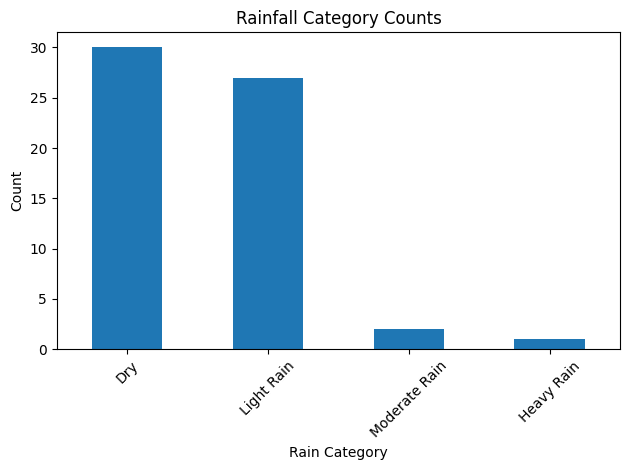

In [24]:
ax = rain_flow_SI_df['Rain_Category'].value_counts().reindex(columns).plot(kind='bar')
ax.set_title('Rainfall Category Counts')
ax.set_xlabel('Rain Category')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()